## Predecir precios de productos

### Y ahora, para evaluar nuestro modelo de código abierto perfeccionado

In [ ]:
# pip installs

!pip install -q datasets==2.21.0 peft requests torch bitsandbytes transformers==4.43.1 trl accelerate sentencepiece matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fssp

In [ ]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import torch.nn.functional as F
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
from peft import PeftModel
import matplotlib.pyplot as plt

In [ ]:
# Constantes

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"
PROJECT_NAME = "pricer"
HF_USER = "joanby" # ¡Tu nombre de HF aquí! O usa el mío si solo quieres reproducir mis resultados.

# Ejecuta tu mismo

RUN_NAME = "2024-12-16_07.57.53"
PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
REVISION = "89ffcb17a8b1f54c610eff8fb1bbbb6a373b6249" # or REVISION = None
FINETUNED_MODEL = f"{HF_USER}/{PROJECT_RUN_NAME}"

# Descomenta esta línea si desea utilizar el modelo de Ed.
# REVISION = "e8d637df551603dc86cd7a1598a8f44af4d7ae36"
# RUN_NAME = "2024-09-13_13.04.39"
# PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
# FINETUNED_MODEL = f"ed-donner/{PROJECT_RUN_NAME}"

# Data

DATASET_NAME = f"{HF_USER}/pricer-data"
# O puedes utilizar el dataset de Ed
# DATASET_NAME = "ed-donner/pricer-data"

# Hiperparámetros para QLoRA

QUANT_4_BIT = True

%matplotlib inline

# Se utiliza para escribir en salida en color.

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

### Inicia sesión en HuggingFace

Si aún no tienes una cuenta de HuggingFace, visita https://huggingface.co para registrarte y crear un token.

Luego, selecciona los secretos para este cuaderno haciendo clic en el ícono de la llave a la izquierda y agrega un nuevo secreto llamado `HF_TOKEN` con el valor como tu token.

In [ ]:
# Log in en HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
test = dataset['test']

Generating train split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
test[0]

{'text': "How much does this cost to the nearest dollar?\n\nOEM AC Compressor w/A/C Repair Kit For Ford F150 F-150 V8 & Lincoln Mark LT 2007 2008 - BuyAutoParts NEW\nAs one of the world's largest automotive parts suppliers, our parts are trusted every day by mechanics and vehicle owners worldwide. This A/C Compressor and Components Kit is manufactured and tested to the strictest OE standards for unparalleled performance. Built for trouble-free ownership and 100% visually inspected and quality tested, this A/C Compressor and Components Kit is backed by our 100% satisfaction guarantee. Guaranteed Exact Fit for easy installation 100% BRAND NEW, premium ISO/TS 16949 quality - tested to meet or exceed OEM specifications Engineered for superior durability, backed by industry-leading unlimited-mileage warranty Included in this K\n\nPrice is $",
 'price': 374.41}

## Vamos a cargar el Tokenizador y el Modelo

In [ ]:
# Elegimos la cuantización adecuada

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

In [ ]:
# Cargamos el Tokenizador y el Modelo

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

# Cargamos el modelo ajustado con PEFT
if REVISION:
  fine_tuned_model = PeftModel.from_pretrained(base_model, FINETUNED_MODEL, revision=REVISION)
else:
  fine_tuned_model = PeftModel.from_pretrained(base_model, FINETUNED_MODEL)


print(f"Impacto en la memoria: {fine_tuned_model.get_memory_footprint() / 1e6:.1f} MB")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

adapter_config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

Impacto en la memoria: 5700.6 MB


In [ ]:
fine_tuned_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaSdpaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): 

# ¡EL MOMENTO DE LA VERDAD!

## Use el modelo en modo de inferencia

Recuerda que GPT-4o tuvo un error promedio de \$76.

El modelo base Llama 3.1 tuvo un error promedio de \$396.

Este humano tuvo un error de \$127.

## Advertencia

Ten en cuenta que los precios de los bienes varían considerablemente; el modelo no puede predecir cosas como precios de venta sobre los cuales no tiene información.

In [ ]:
def extract_price(s):
    if "Price is $" in s:
      contents = s.split("Price is $")[1]
      contents = contents.replace(',','')
      match = re.search(r"[-+]?\d*\.\d+|\d+", contents)
      return float(match.group()) if match else 0
    return 0

In [ ]:
extract_price("Price is $a fabulous 899.99 or so")

899.99

In [ ]:
# La función de predicción original toma el siguiente token más probable

def model_predict(prompt):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to("cuda")
    attention_mask = torch.ones(inputs.shape, device="cuda")
    outputs = fine_tuned_model.generate(inputs, attention_mask=attention_mask, max_new_tokens=3, num_return_sequences=1)
    response = tokenizer.decode(outputs[0])
    return extract_price(response)

In [ ]:
# Una función de predicción mejorada toma un promedio ponderado de las 3 opciones principales
# Este código sería más complejo si no pudiéramos aprovechar el hecho
# de que Llama genera 1 token para cualquier número de 3 dígitos

top_K = 3

def improved_model_predict(prompt, device="cuda"):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)
    attention_mask = torch.ones(inputs.shape, device=device)

    with torch.no_grad():
        outputs = fine_tuned_model(inputs, attention_mask=attention_mask)
        next_token_logits = outputs.logits[:, -1, :].to('cpu')

    next_token_probs = F.softmax(next_token_logits, dim=-1)
    top_prob, top_token_id = next_token_probs.topk(top_K)
    prices, weights = [], []
    for i in range(top_K):
      predicted_token = tokenizer.decode(top_token_id[0][i])
      probability = top_prob[0][i]
      try:
        result = float(predicted_token)
      except ValueError as e:
        result = 0.0
      if result > 0:
        prices.append(result)
        weights.append(probability)
    if not prices:
      return 0.0, 0.0
    total = sum(weights)
    weighted_prices = [price * weight / total for price, weight in zip(prices, weights)]
    return sum(weighted_prices).item()

In [ ]:
class Tester:

    def __init__(self, predictor, data, title=None, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint["text"])
        truth = datapoint["price"]
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint["text"].split("\n\n")[1][:20] + "..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Valor Real')
        plt.ylabel('Estimación del Modelo')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


1: Guess: $324.15 Truth: $374.41 Error: $50.26 SLE: 0.02 Item: OEM AC Compressor w/...
2: Guess: $160.56 Truth: $225.11 Error: $64.55 SLE: 0.11 Item: Motorcraft YB3125 Fa...
3: Guess: $55.47 Truth: $61.68 Error: $6.21 SLE: 0.01 Item: Dorman Front Washer ...
4: Guess: $706.16 Truth: $599.99 Error: $106.17 SLE: 0.03 Item: HP Premium HD Plus T...
5: Guess: $39.33 Truth: $16.99 Error: $22.34 SLE: 0.65 Item: Super Switch Pickup ...
6: Guess: $19.04 Truth: $31.99 Error: $12.95 SLE: 0.25 Item: Horror Bookmarks, Re...
7: Guess: $80.51 Truth: $101.79 Error: $21.28 SLE: 0.05 Item: SK6241 - Stinger 4 G...
8: Guess: $233.74 Truth: $289.00 Error: $55.26 SLE: 0.04 Item: Godox ML60Bi LED Lig...
9: Guess: $704.08 Truth: $635.86 Error: $68.22 SLE: 0.01 Item: Randall G3 Plus Comb...
10: Guess: $262.84 Truth: $65.99 Error: $196.85 SLE: 1.88 Item: HOLDWILL 6 Pack LED ...
11: Guess: $260.88 Truth: $254.21 Error: $6.67 SLE: 0.00 Item: Viking Horns 3 Gallo...
12: Guess: $236.44 Truth: $412.99 Error: $176.55 

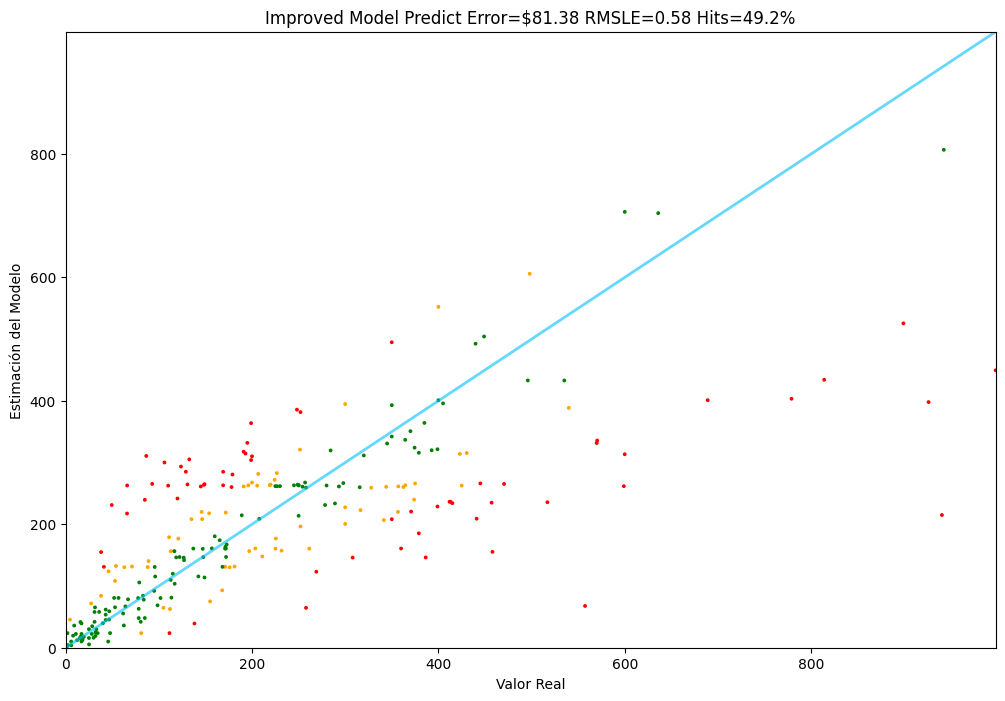

In [ ]:
Tester.test(improved_model_predict, test)

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


1: Guess: $373.54 Truth: $374.41 Error: $0.87 SLE: 0.00 Item: OEM AC Compressor w/...
2: Guess: $160.79 Truth: $225.11 Error: $64.32 SLE: 0.11 Item: Motorcraft YB3125 Fa...
3: Guess: $40.08 Truth: $61.68 Error: $21.60 SLE: 0.18 Item: Dorman Front Washer ...
4: Guess: $415.56 Truth: $599.99 Error: $184.43 SLE: 0.13 Item: HP Premium HD Plus T...
5: Guess: $18.31 Truth: $16.99 Error: $1.32 SLE: 0.01 Item: Super Switch Pickup ...
6: Guess: $16.93 Truth: $31.99 Error: $15.06 SLE: 0.37 Item: Horror Bookmarks, Re...
7: Guess: $116.63 Truth: $101.79 Error: $14.84 SLE: 0.02 Item: SK6241 - Stinger 4 G...
8: Guess: $296.94 Truth: $289.00 Error: $7.94 SLE: 0.00 Item: Godox ML60Bi LED Lig...
9: Guess: $859.96 Truth: $635.86 Error: $224.10 SLE: 0.09 Item: Randall G3 Plus Comb...
10: Guess: $65.78 Truth: $65.99 Error: $0.21 SLE: 0.00 Item: HOLDWILL 6 Pack LED ...
11: Guess: $214.77 Truth: $254.21 Error: $39.44 SLE: 0.03 Item: Viking Horns 3 Gallo...
12: Guess: $381.52 Truth: $412.99 Error: $31.47 SLE

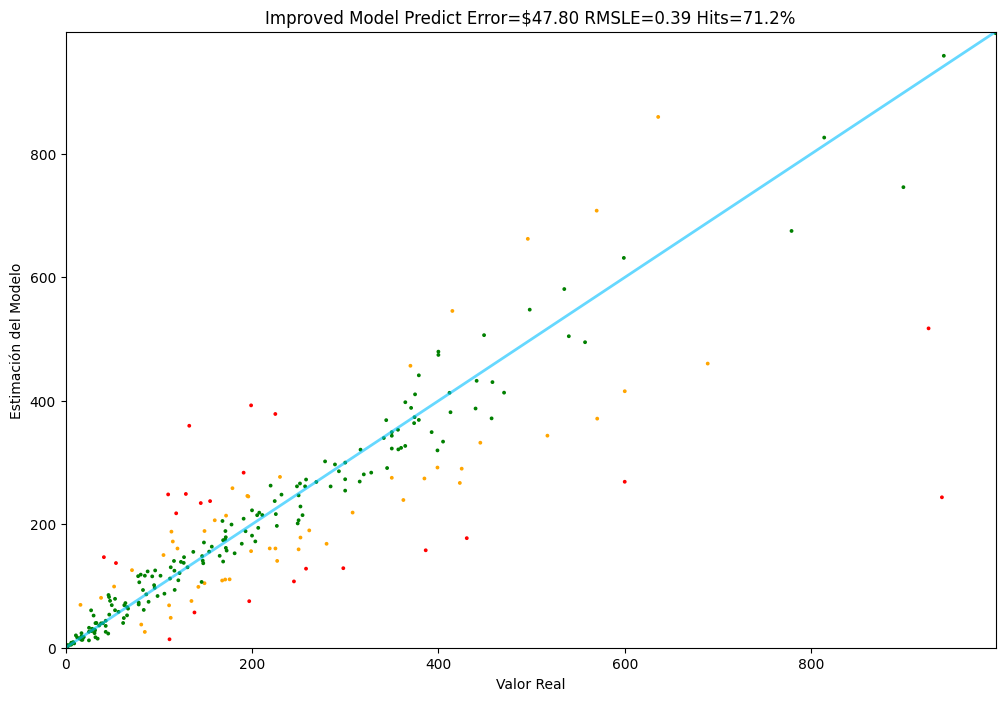

In [ ]:
Tester.test(improved_model_predict, test)